In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

BASE_DIR = Path.cwd()

RESULT_DIR = (
    BASE_DIR
    / "data_set"
    / "07_분석결과"
)

# 결과 데이터
national = pd.read_csv(
    RESULT_DIR / "전국_집계구별_AED_접근성.csv",
    encoding="utf-8-sig"
)

seoul = pd.read_csv(
    RESULT_DIR / "서울_집계구별_AED_접근성.csv",
    encoding="utf-8-sig"
)

dong = pd.read_csv(
    RESULT_DIR / "서울_행정동별_AED_접근성.csv",
    encoding="utf-8-sig"
)

district = pd.read_csv(
    RESULT_DIR / "서울_자치구별_AED_접근성.csv",
    encoding="utf-8-sig"
)

print("전국 집계구:", len(national))
print("서울 집계구:", len(seoul))
print("서울 행정동:", len(dong))
print("서울 자치구:", len(district))

전국 집계구: 108510
서울 집계구: 19097
서울 행정동: 426
서울 자치구: 25


In [ ]:
# 서울 전체 분석 대상
seoul_valid = seoul[
    seoul["격자인구"] > 0
].copy()

total_population = seoul_valid["격자인구"].sum()

distance_result = []

for distance in [100, 200, 300]:
    
    accessible = (
        seoul_valid[f"접근{distance}m_인구"]
        .sum()
    )
    
    rate = (
        accessible
        / total_population
        * 100
    )
    
    distance_result.append(
        {
            "거리": distance,
            "접근율": rate
        }
    )

distance_result = pd.DataFrame(distance_result)

distance_result

,거리,접근률
0,100,46.069811
1,200,89.624631
2,300,98.829917


findfont: Failed to find font weight bold, now using 400.


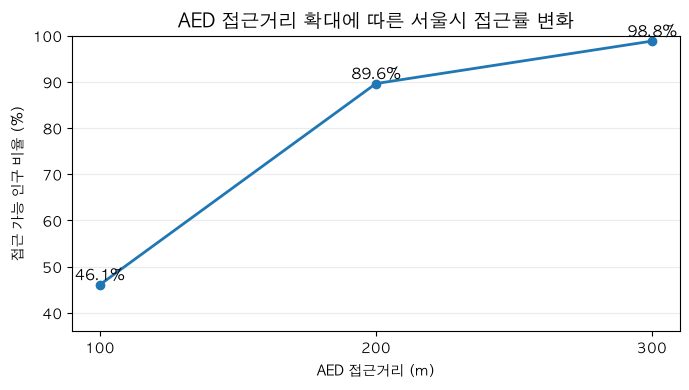

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    distance_result["거리"],
    distance_result["접근율"],
    marker="o",
    linewidth=2
)

for x, y in zip(
    distance_result["거리"],
    distance_result["접근율"]
):
    ax.text(
        x,
        y + 1,
        f"{y:.1f}%",
        ha="center",
        fontsize=11
    )

ax.set_xticks([100, 200, 300])
ax.set_xlabel("AED 접근거리 (m)")
ax.set_ylabel("접근 가능 인구 비율 (%)")

ax.set_title(
    "AED 접근거리 확대에 따른 서울시 접근율 변화",
    fontsize=14,
    fontweight="bold"
)

ax.set_ylim(
    max(0, distance_result["접근율"].min() - 10),
    100
)

ax.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()
plt.show()

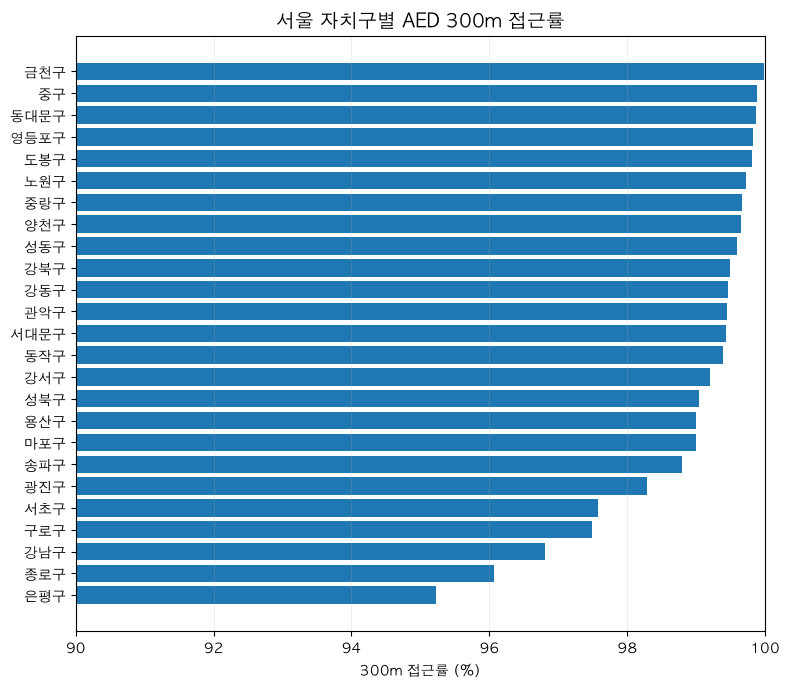

In [ ]:
district_access = (
    district[
        [
            "시군구명",
            "300m_접근율"
        ]
    ]
    .dropna()
    .sort_values(
        "300m_접근율"
    )
)

fig, ax = plt.subplots(figsize=(8, 7))

bars = ax.barh(
    district_access["시군구명"],
    district_access["300m_접근율"]
)

ax.set_xlabel("300m 접근율 (%)")

ax.set_title(
    "서울 자치구별 AED 300m 접근율",
    fontsize=14,
    fontweight="bold"
)

# 실제 최소값 기준으로 축 축소
minimum = (
    np.floor(
        district_access["300m_접근율"].min()
        / 10
    )
    * 10
)

ax.set_xlim(
    max(0, minimum),
    100
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

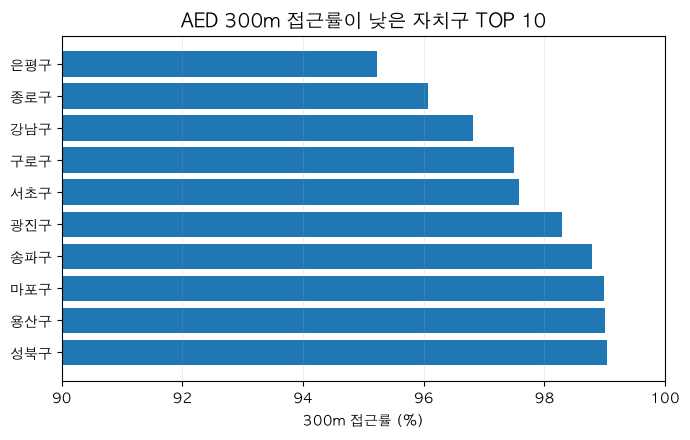

In [ ]:
bottom10 = (
    district
    .nsmallest(
        10,
        "300m_접근율"
    )
    .sort_values(
        "300m_접근율",
        ascending=False
    )
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.barh(
    bottom10["시군구명"],
    bottom10["300m_접근율"]
)

ax.set_xlabel("300m 접근율 (%)")

ax.set_title(
    "AED 300m 접근율이 낮은 자치구 TOP 10",
    fontsize=14,
    fontweight="bold"
)

minimum = (
    np.floor(
        bottom10["300m_접근율"].min()
        / 10
    )
    * 10
)

ax.set_xlim(
    max(0, minimum),
    100
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

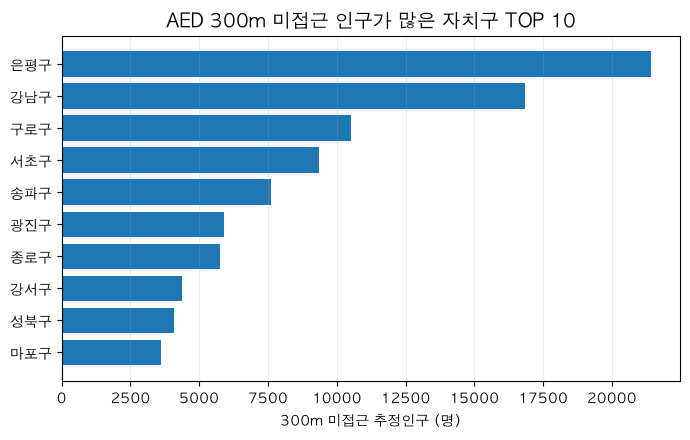

In [6]:
unaccess_top10 = (
    district
    .nlargest(
        10,
        "300m_미접근인구"
    )
    .sort_values(
        "300m_미접근인구"
    )
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.barh(
    unaccess_top10["시군구명"],
    unaccess_top10["300m_미접근인구"]
)

ax.set_xlabel("300m 미접근 추정인구 (명)")

ax.set_title(
    "AED 300m 미접근 인구가 많은 자치구 TOP 10",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

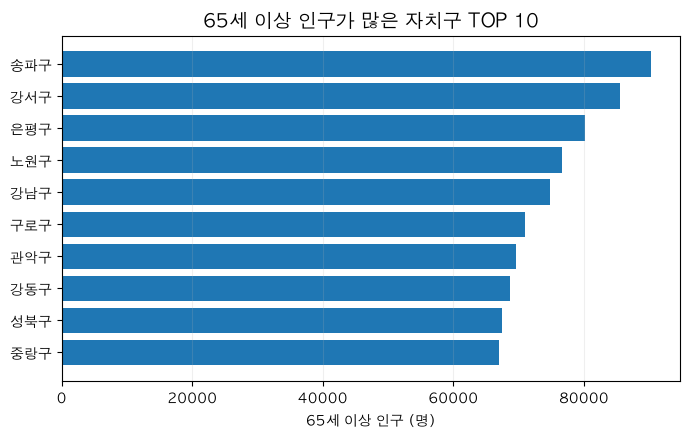

In [7]:
elderly_top10 = (
    district
    .nlargest(
        10,
        "65세이상인구"
    )
    .sort_values(
        "65세이상인구"
    )
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.barh(
    elderly_top10["시군구명"],
    elderly_top10["65세이상인구"]
)

ax.set_xlabel("65세 이상 인구 (명)")

ax.set_title(
    "65세 이상 인구가 많은 자치구 TOP 10",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

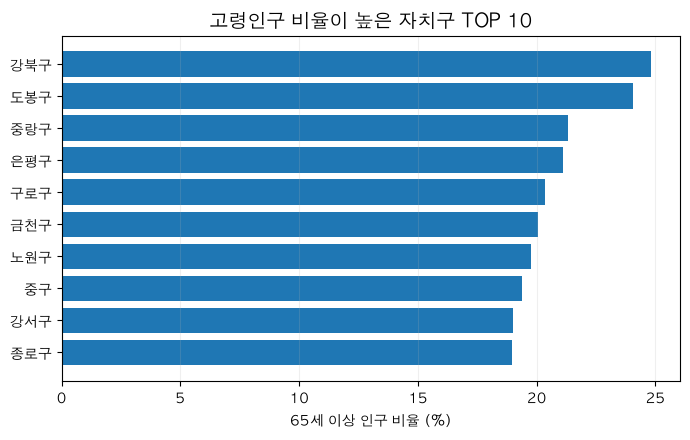

In [8]:
elderly_ratio_top10 = (
    district
    .nlargest(
        10,
        "고령인구비율"
    )
    .sort_values(
        "고령인구비율"
    )
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.barh(
    elderly_ratio_top10["시군구명"],
    elderly_ratio_top10["고령인구비율"]
)

ax.set_xlabel("65세 이상 인구 비율 (%)")

ax.set_title(
    "고령인구 비율이 높은 자치구 TOP 10",
    fontsize=14,
    fontweight="bold"
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

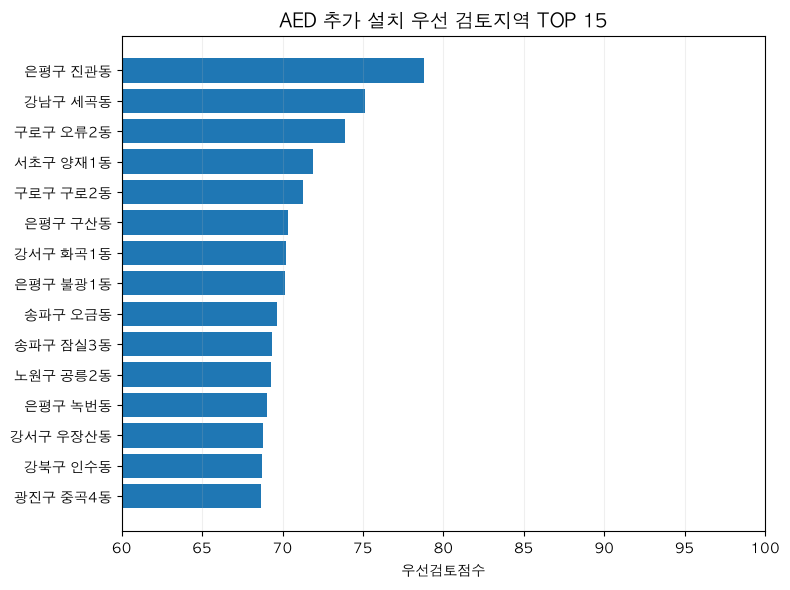

In [9]:
priority_top15 = (
    dong
    .dropna(
        subset=[
            "우선검토점수"
        ]
    )
    .nlargest(
        15,
        "우선검토점수"
    )
    .sort_values(
        "우선검토점수"
    )
)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh(
    priority_top15["지역명"],
    priority_top15["우선검토점수"]
)

ax.set_xlabel("우선검토점수")

ax.set_title(
    "AED 추가 설치 우선 검토지역 TOP 15",
    fontsize=14,
    fontweight="bold"
)

minimum = (
    np.floor(
        priority_top15["우선검토점수"].min()
        / 10
    )
    * 10
)

ax.set_xlim(
    max(0, minimum),
    100
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [10]:
# 접근성 취약점수
# +
# 미접근인구점수
# +
# 인구점수
# +
# 고령인구점수

In [11]:
priority_component = (
    dong
    .dropna(
        subset=[
            "우선검토점수"
        ]
    )
    .nlargest(
        10,
        "우선검토점수"
    )
    .copy()
)


# 각각 최종점수에 기여하는 점수
priority_component["접근성"] = (
    priority_component["접근성취약점수"]
    * 25
)

priority_component["미접근인구"] = (
    priority_component["미접근인구점수"]
    * 25
)

priority_component["전체인구"] = (
    priority_component["인구점수"]
    * 25
)

priority_component["고령인구"] = (
    priority_component["고령인구점수"]
    * 25
)


priority_component = (
    priority_component
    .sort_values(
        "우선검토점수"
    )
)

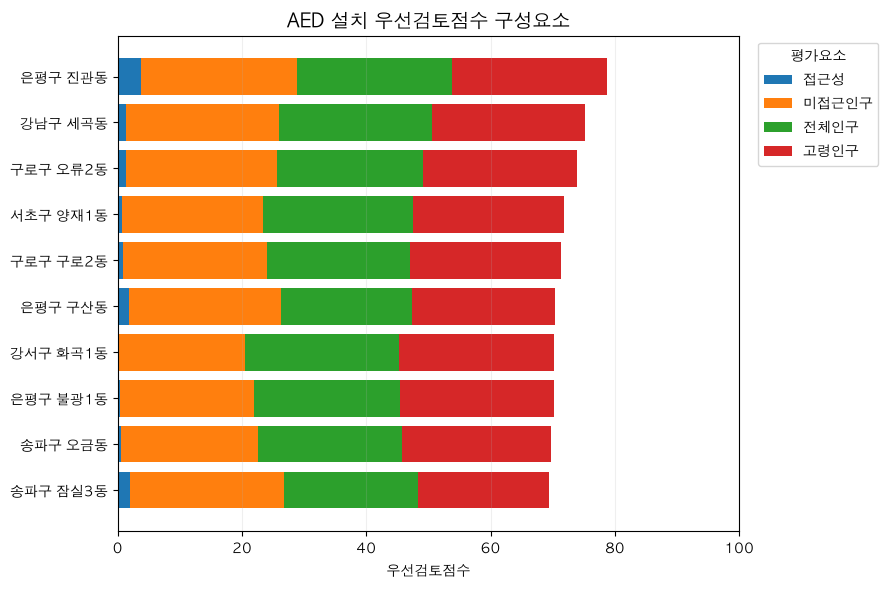

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

left = np.zeros(
    len(priority_component)
)

columns = [
    "접근성",
    "미접근인구",
    "전체인구",
    "고령인구"
]

for column in columns:

    ax.barh(
        priority_component["지역명"],
        priority_component[column],
        left=left,
        label=column
    )

    left += (
        priority_component[column]
        .to_numpy()
    )


ax.set_xlabel(
    "우선검토점수"
)

ax.set_title(
    "AED 설치 우선검토점수 구성요소",
    fontsize=14,
    fontweight="bold"
)

ax.legend(
    title="평가요소",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.set_xlim(
    0,
    100
)

ax.grid(
    axis="x",
    alpha=0.2
)

plt.tight_layout()
plt.show()

In [ ]:
# st.divider()

# st.header('1. 대한민국 전체 AED 접근성 현황')

# st.caption('전국적인 AED 접근성 차이를 확인한 뒤 서울특별시를 대상으로 상세 분석을 진행합니다.')

# valid_national = national[national['격자인구'] > 0].copy()

# national_rate_col = f'{distance}m_접근율'

# national_fig, national_ax = plt.subplots(figsize=(7, 7))

# national_map = valid_national[valid_national[national_rate_col].notna()].copy()

# national_min = national_map[national_rate_col].min()

# national_color_min = math.floor(national_min / 10) * 10

# national_color_min = max(national_color_min, 0)

# national_map.plot(column=national_rate_col, cmap="cividis", legend=True, ax=national_ax, edgecolor="none",
#     linewidth=0, vmin=national_color_min, vmax=100, legend_kwds={"label" : f"AED {distance}m 접근율 (%)", "shrink" : 0.65,},
# )

# national_ax.set_title(f'대한민국 AED {distance}m 접근율', fontsize=12)

# national_ax.axis('off')

# plt.tight_layout()

# st.pyplot(national_fig, use_container_width=False)
